In [1]:
"""
BC (Behavior Cloning) Trainer for Variable Admittance Control
Peg-in-Hole Task Implementation

This notebook implements supervised behavior cloning*:
- Learn a policy pi(a|s) by minimizing MSE between policy action and expert action.
- No discriminator, no AIRL reward, no PPO.

Variable Admittance Control:
- State Space (12D): [e_t(3), pd_t(3), e_r(3), rd_t(3)]
- Action Space (7D): [K1, K2, K3, K4, K5, K6, damping_ratio]
- Damping matrix: B = damping_ratio * sqrt(K)
"""

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import pickle
import matplotlib.pyplot as plt
from collections import deque
import random
from typing import Dict, List, Tuple, Optional
import logging

current_dir = os.getcwd()

if 'mujoco_wrappers' in current_dir:
    if not current_dir.endswith('mujoco_wrappers'):
        root_path = current_dir.split('mujoco_wrappers')[0] + 'mujoco_wrappers'
        os.chdir(root_path)
        print(f"Changed working directory to: {os.getcwd()}")
else:
    print("Warning: Could not find mujoco_wrappers in current path")

# Add path for environment (kept for interface compatibility / optional evaluation)
sys.path.append(os.getcwd())

from envs.peg_in_hole_env import PegInHoleEnv

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Working directory: {os.getcwd()}")


Changed working directory to: /home/auksphere/robotics/mujoco_wrappers
Using device: cuda
Working directory: /home/auksphere/robotics/mujoco_wrappers
Using device: cuda
Working directory: /home/auksphere/robotics/mujoco_wrappers


In [2]:
class VariableImpedancePolicy(nn.Module):
    """Policy network for impedance learning"""
    def __init__(self, state_dim=12, action_dim=7, hidden_dim=128):
        super(VariableImpedancePolicy, self).__init__()
        
        self.error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.position_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_error_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.rot_desired_encoder = nn.Sequential(
            nn.Linear(3, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        self.shared_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )
        
        self.stiffness_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 12)
        )
        
        self.damping_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 2)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.8)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        
        with torch.no_grad():
            self.stiffness_branch[-1].weight.data *= 0.5
            self.stiffness_branch[-1].bias.data[:6] = 0.3
            self.stiffness_branch[-1].bias.data[6:] = -0.7
            
            self.damping_branch[-1].weight.data *= 0.7
            self.damping_branch[-1].bias.data[0] = 0.2
            self.damping_branch[-1].bias.data[1] = -0.5
    
    def forward(self, state):
        if torch.isnan(state).any():
            state = torch.where(torch.isnan(state), torch.zeros_like(state), state)
        
        tracking_error = state[:, :3]
        desired_position = state[:, 3:6]
        rot_error = state[:, 6:9]
        desired_rot = state[:, 9:12]
        
        error_features = self.error_encoder(tracking_error)
        position_features = self.position_encoder(desired_position)
        rot_error_features = self.rot_error_encoder(rot_error)
        rot_desired_features = self.rot_desired_encoder(desired_rot)
        
        combined_features = torch.cat(
            [error_features, position_features, rot_error_features, rot_desired_features], dim=-1
        )
        shared_features = self.shared_net(combined_features)
        
        stiffness_output = self.stiffness_branch(shared_features)
        damping_output = self.damping_branch(shared_features)
        
        stiffness_mean = stiffness_output[:, :6]
        stiffness_log_std = stiffness_output[:, 6:]
        damping_mean = damping_output[:, 0:1]
        damping_log_std = damping_output[:, 1:2]
        
        mean = torch.cat([stiffness_mean, damping_mean], dim=-1)
        log_std = torch.cat([stiffness_log_std, damping_log_std], dim=-1)
        
        mean = torch.clamp(mean, min=-2.5, max=2.5)
        log_std = torch.clamp(log_std, min=-1.0, max=0.7)
        
        return mean, log_std
    
    def sample_action(self, state):
        """Sample action with tanh squashing to [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.03, max=1.0)
        
        try:
            dist = Normal(mean, std)
            z = dist.rsample()
            action = torch.tanh(z)
            
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            log_prob = torch.clamp(log_prob, min=-12, max=12)
            
            return action, log_prob
        except Exception:
            action = torch.tanh(mean)
            log_prob = torch.zeros(action.shape[0], device=action.device)
            return action, log_prob
    
    def evaluate_action(self, state, action):
        """Evaluate log probability of given action in [-1, 1]"""
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        std = torch.clamp(std, min=0.03, max=1.0)
        
        action = torch.clamp(action, min=-0.999, max=0.999)
        z = 0.5 * torch.log((1 + action) / (1 - action + 1e-8))
        
        try:
            dist = Normal(mean, std)
            log_prob = dist.log_prob(z).sum(dim=-1)
            log_prob -= torch.log(1 - action.pow(2) + 1e-8).sum(dim=-1)
            return torch.clamp(log_prob, min=-12, max=12)
        except Exception:
            return torch.zeros(action.shape[0], device=action.device)
    
    def get_deterministic_action(self, state):
        """Deterministic action for evaluation"""
        mean, _ = self.forward(state)
        return torch.tanh(mean)


In [3]:
class ExpertDataLoader:
    def __init__(self, data_file: str, batch_size: int = 256, shuffle: bool = True):
        self.data_file = data_file
        self.batch_size = batch_size
        self.shuffle = shuffle

        # Load expert demonstrations
        with open(data_file, 'rb') as f:
            self.data = pickle.load(f)

        self.actions = np.asarray(self.data['actions'])
        self.observations = np.asarray(self.data['observations'])
        self.num_samples = len(self.actions)

        # Normalization stats
        # Some expert pickles may not contain precomputed min/max; fall back to computing them.
        if all(k in self.data for k in ['state_min', 'state_max', 'action_min', 'action_max']):
            self.state_min = np.asarray(self.data['state_min'], dtype=np.float32)
            self.state_max = np.asarray(self.data['state_max'], dtype=np.float32)
            self.action_min = np.asarray(self.data['action_min'], dtype=np.float32)
            self.action_max = np.asarray(self.data['action_max'], dtype=np.float32)
            logger.info('Loaded normalization stats from expert pickle')
        else:
            self.state_min = self.observations.min(axis=0).astype(np.float32)
            self.state_max = self.observations.max(axis=0).astype(np.float32)
            self.action_min = self.actions.min(axis=0).astype(np.float32)
            self.action_max = self.actions.max(axis=0).astype(np.float32)
            missing = [k for k in ['state_min', 'state_max', 'action_min', 'action_max'] if k not in self.data]
            logger.warning(f"Expert pickle missing stats {missing}; computed min/max from data")

        logger.info(f"Loaded {self.num_samples} expert demonstrations")

    def normalize_states(self, states: np.ndarray) -> np.ndarray:
        denom = (self.state_max - self.state_min)
        return 2.0 * (states - self.state_min) / (denom + 1e-8) - 1.0

    def normalize_actions(self, actions: np.ndarray) -> np.ndarray:
        denom = (self.action_max - self.action_min)
        return 2.0 * (actions - self.action_min) / (denom + 1e-8) - 1.0

    def denormalize_actions(self, actions: np.ndarray) -> np.ndarray:
        return (actions + 1.0) * 0.5 * (self.action_max - self.action_min) + self.action_min

    def get_batches(self):
        indices = np.arange(self.num_samples)
        if self.shuffle:
            np.random.shuffle(indices)

        for start_idx in range(0, self.num_samples, self.batch_size):
            batch_indices = indices[start_idx:start_idx + self.batch_size]

            batch_obs = self.observations[batch_indices]
            batch_actions = self.actions[batch_indices]

            batch_obs_norm = self.normalize_states(batch_obs)
            batch_actions_norm = self.normalize_actions(batch_actions)

            yield (
                torch.FloatTensor(batch_obs_norm).to(device),
                torch.FloatTensor(batch_actions_norm).to(device),
            )

    def get_all_data(self):
        obs_norm = self.normalize_states(self.observations)
        actions_norm = self.normalize_actions(self.actions)
        return (
            torch.FloatTensor(obs_norm).to(device),
            torch.FloatTensor(actions_norm).to(device),
        )


class BCSupervisedTrainer:
    """Pure supervised BC trainer (MSE on normalized actions)."""

    def __init__(
        self,
        policy: 'VariableImpedancePolicy',
        expert_loader: ExpertDataLoader,
        lr: float = 3e-4,
        weight_decay: float = 0.0,
        grad_clip: float = 1.0,
    ):
        self.policy = policy
        self.expert_loader = expert_loader
        self.grad_clip = grad_clip

        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr, weight_decay=weight_decay)

    def train_epoch(self) -> Dict[str, float]:
        self.policy.train()
        losses: List[float] = []

        for states, actions in self.expert_loader.get_batches():
            pred_actions, _ = self.policy(states)
            loss = F.mse_loss(pred_actions, actions)

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if self.grad_clip is not None and self.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(self.policy.parameters(), self.grad_clip)
            self.optimizer.step()

            losses.append(float(loss.item()))

        return {
            'bc_loss': float(np.mean(losses)) if losses else float('nan'),
        }

    @torch.no_grad()
    def evaluate(self, states: torch.Tensor, actions: torch.Tensor) -> Dict[str, float]:
        self.policy.eval()
        pred_actions, _ = self.policy(states)
        loss = F.mse_loss(pred_actions, actions).item()
        return {'bc_loss': float(loss)}


In [4]:
def main(
    expert_data_file: str = 'data/expert_demonstration.pkl',
    output_dir: str = 'script/models/bc',
    num_epochs: int = 200,
    batch_size: int = 256,
    lr: float = 3e-4,
    weight_decay: float = 0.0,
    grad_clip: float = 1.0,
    eval_every: int = 10,
    seed: int = 42,
    plot: bool = True,
):
    """Train a BC policy from expert demonstrations.

    Interface notes (kept stable):
    - Loads expert pickle with keys: observations/actions and min/max stats.
    - Saves policy with the same filename as before: policy.pt
    - Output directory is now `script/models/bc/`.
    """

    # Reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    os.makedirs(output_dir, exist_ok=True)

    # Load expert data
    expert_loader = ExpertDataLoader(expert_data_file, batch_size=batch_size, shuffle=True)

    # Create policy
    state_dim = expert_loader.observations.shape[1]
    action_dim = expert_loader.actions.shape[1]
    logger.info(f"State dim: {state_dim}, Action dim: {action_dim}")

    policy = VariableImpedancePolicy(state_dim, action_dim).to(device)

    trainer = BCSupervisedTrainer(
        policy=policy,
        expert_loader=expert_loader,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
    )

    # Metrics
    train_losses: List[float] = []
    eval_losses: List[Tuple[int, float]] = []

    # Fixed eval batch
    eval_states, eval_actions = expert_loader.get_all_data()

    for epoch in range(1, num_epochs + 1):
        metrics = trainer.train_epoch()
        train_losses.append(metrics['bc_loss'])

        if (epoch % eval_every) == 0 or epoch == 1 or epoch == num_epochs:
            eval_metrics = trainer.evaluate(eval_states, eval_actions)
            eval_losses.append((epoch, eval_metrics['bc_loss']))
            logger.info(
                f"Epoch {epoch:4d}/{num_epochs} | "
                f"train_bc_loss={metrics['bc_loss']:.6f} | "
                f"eval_bc_loss={eval_metrics['bc_loss']:.6f}"
            )

    # Save policy (keep filename stable)
    policy_path = os.path.join(output_dir, 'policy.pt')
    torch.save(policy.state_dict(), policy_path)
    logger.info(f"Saved BC policy to: {policy_path}")

    # Save normalization stats for downstream usage (non-breaking extra)
    stats_path = os.path.join(output_dir, 'norm_stats.pkl')
    with open(stats_path, 'wb') as f:
        pickle.dump(
            {
                'state_min': expert_loader.state_min,
                'state_max': expert_loader.state_max,
                'action_min': expert_loader.action_min,
                'action_max': expert_loader.action_max,
            },
            f,
        )
    logger.info(f"Saved normalization stats to: {stats_path}")

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='train bc_loss')
        if eval_losses:
            xs = [x for x, _ in eval_losses]
            ys = [y for _, y in eval_losses]
            plt.plot([x - 1 for x in xs], ys, 'o-', label='eval bc_loss')
        plt.xlabel('epoch')
        plt.ylabel('MSE (normalized actions)')
        plt.title('Behavior Cloning Training')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



INFO:__main__:Loaded 10981 expert demonstrations
INFO:__main__:State dim: 12, Action dim: 7
INFO:__main__:Loaded 10981 expert demonstrations
INFO:__main__:State dim: 12, Action dim: 7
INFO:__main__:Epoch    1/200 | train_bc_loss=0.465686 | eval_bc_loss=0.286658
INFO:__main__:Epoch    1/200 | train_bc_loss=0.465686 | eval_bc_loss=0.286658
INFO:__main__:Epoch   10/200 | train_bc_loss=0.025593 | eval_bc_loss=0.016605
INFO:__main__:Epoch   10/200 | train_bc_loss=0.025593 | eval_bc_loss=0.016605
INFO:__main__:Epoch   20/200 | train_bc_loss=0.013784 | eval_bc_loss=0.008696
INFO:__main__:Epoch   20/200 | train_bc_loss=0.013784 | eval_bc_loss=0.008696
INFO:__main__:Epoch   30/200 | train_bc_loss=0.009899 | eval_bc_loss=0.006313
INFO:__main__:Epoch   30/200 | train_bc_loss=0.009899 | eval_bc_loss=0.006313
INFO:__main__:Epoch   40/200 | train_bc_loss=0.008084 | eval_bc_loss=0.005867
INFO:__main__:Epoch   40/200 | train_bc_loss=0.008084 | eval_bc_loss=0.005867
INFO:__main__:Epoch   50/200 | train

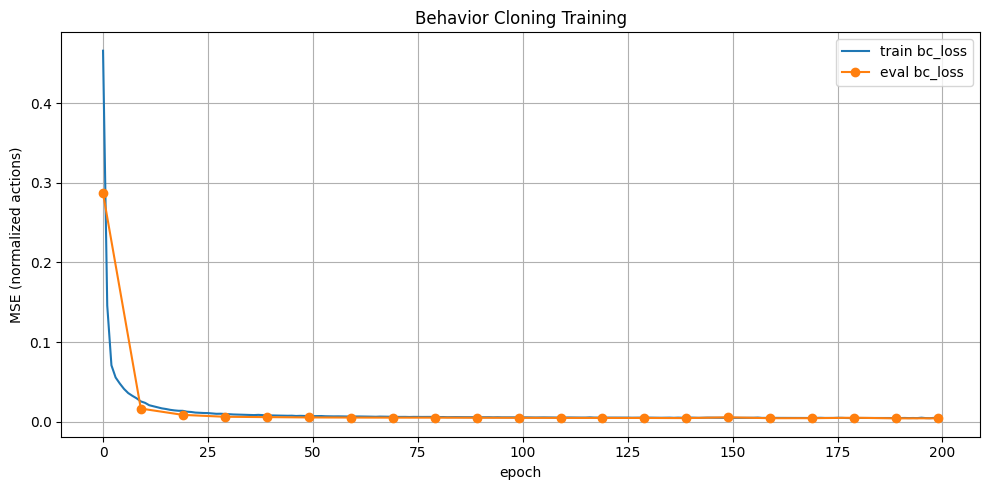

In [5]:
main()
